# Figure 6 — CV uplift@k curves for four targeting strategies (IBM Employee Attrition, B&W)

Reads `article/results/cv_rule_records.csv` and reproduces the uplift@k curve for the four targeting strategies (`point`, `lower`, `lower_positive`, `risk_adjusted`) on the smallest dataset, where the strategies separate most visibly.

The chosen dataset is **IBM Employee Attrition** (1{,}470 rows): in the larger datasets (Bank Marketing, Credit Card Default) the four strategies overlap to within line width, so the figure would be uninformative. Attrition's wide fold-to-fold spread also illustrates the small-sample uncertainty that motivates Section 6.

**Output:** `article/figures/fig6_cv_uplift_strategies.pdf`.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
if str(REPO / 'notebooks' / 'article' / 'figures') not in sys.path:
    sys.path.insert(0, str(REPO / 'notebooks' / 'article' / 'figures'))
from _style import DOUBLE_COL_INCHES, apply_rc
import matplotlib.pyplot as plt
apply_rc()
CSV = REPO / 'article' / 'results' / 'cv_rule_records.csv'
PDF = REPO / 'article' / 'figures' / 'fig6_cv_uplift_strategies.pdf'
df = pd.read_csv(CSV)
df = df[df['dataset'] == 'IBM Employee Attrition'].copy()
print('records:', df.shape, 'folds:', sorted(df['fold'].unique()))

records: (149, 12) folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


wrote article\figures\fig6_cv_uplift_strategies.pdf


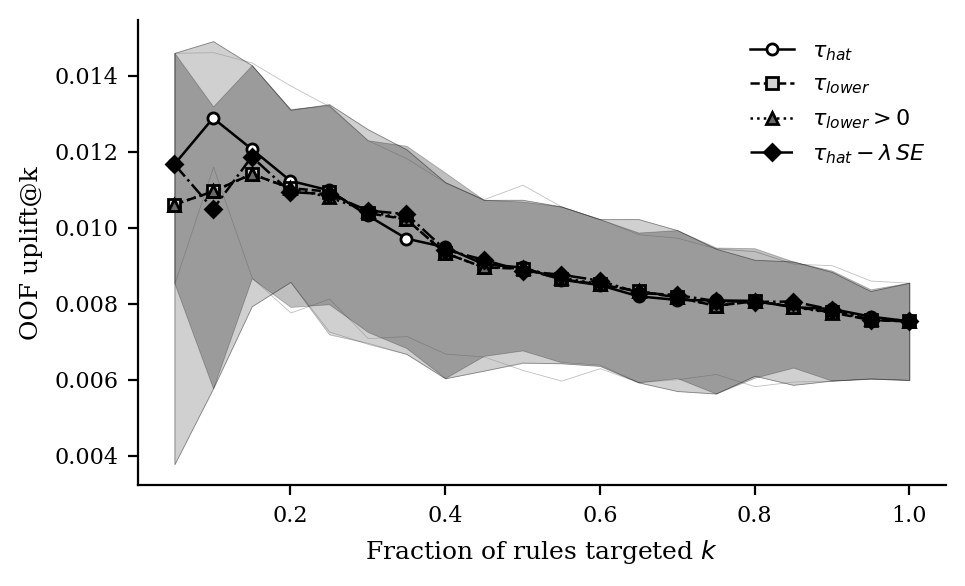

In [2]:
def _score(record, strategy, risk_lambda=1.96):
    pt = record['train_uplift']
    lo = record['train_uplift_lower']
    se = record['train_uplift_se']
    if strategy == 'point':           return pt
    if strategy == 'lower':           return lo
    if strategy == 'lower_positive':  return lo if lo > 0 else -np.inf
    if strategy == 'risk_adjusted':   return pt - risk_lambda * se
    raise ValueError(strategy)

STRATEGIES = ['point', 'lower', 'lower_positive', 'risk_adjusted']
STYLE = {
    'point':           dict(linestyle='-',   marker='o', face='white',     edge='black'),
    'lower':           dict(linestyle='--',  marker='s', face='lightgray', edge='black'),
    'lower_positive':  dict(linestyle=':',   marker='^', face='dimgray',   edge='black'),
    'risk_adjusted':   dict(linestyle='-.',  marker='D', face='black',     edge='black'),
}
LABEL = {
    'point': r'$\tau_{hat}$',
    'lower': r'$\tau_{lower}$',
    'lower_positive': r'$\tau_{lower}>0$',
    'risk_adjusted': r'$\tau_{hat}-\lambda\,SE$',
}

k_grid = np.linspace(0.05, 1.0, 20)
fig, ax = plt.subplots(figsize=(DOUBLE_COL_INCHES * 0.7, 3.0))
for strategy in STRATEGIES:
    fold_curves = []
    for fold_idx, fold_df in df.groupby('fold'):
        records = fold_df.to_dict(orient='records')
        scores = np.array([_score(r, strategy) for r in records])
        test_uplift = fold_df['test_uplift'].to_numpy()
        valid = np.isfinite(scores)
        if not valid.any():
            continue
        s = scores[valid]
        o = test_uplift[valid]
        order = np.argsort(-s)
        sorted_o = o[order]
        n = len(sorted_o)
        curve_y = []
        for k in k_grid:
            top = max(1, int(np.ceil(n * k)))
            curve_y.append(float(np.mean(sorted_o[:top])))
        fold_curves.append(curve_y)
    if not fold_curves:
        continue
    arr = np.asarray(fold_curves)
    mean = arr.mean(axis=0)
    lo = np.quantile(arr, 0.025, axis=0) if arr.shape[0] >= 3 else arr.min(axis=0)
    hi = np.quantile(arr, 0.975, axis=0) if arr.shape[0] >= 3 else arr.max(axis=0)
    style = STYLE[strategy]
    ax.plot(k_grid, mean, marker=style['marker'], linestyle=style['linestyle'],
            markerfacecolor=style['face'], markeredgecolor=style['edge'], color='black',
            markersize=4, linewidth=0.9, label=LABEL[strategy])
    ax.fill_between(k_grid, lo, hi, color=style['face'], edgecolor='black', linewidth=0.3, alpha=0.25)
ax.set_xlabel('Fraction of rules targeted $k$')
ax.set_ylabel('OOF uplift@k')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig(PDF, format='pdf', bbox_inches='tight')
print('wrote', PDF.relative_to(REPO))
plt.show()